# Parcial 1 — Analítica de Datos

**Base de datos:** Pima Indians Diabetes (NIDDK). Clasificación binaria: `Outcome` (0 = no diabetes, 1 = diabetes).

**Flujo de minería predictiva:** *Preparación de datos → División → Aprendizaje → Evaluación → Despliegue*.

**Variables predictoras (6):** `Pregnancies`, `Glucose`, `BloodPressure`, `BMI`, `DiabetesPedigreeFunction`, `Age`.

In [1]:
%%capture
# --- Configuración inicial ---
import numpy as np, pandas as pd, os, json, pickle, warnings
warnings.filterwarnings("ignore")
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.05)

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)

# Rutas
BASE = "../datos_clinicos/files"      # donde están las fuentes
OUT = ".."                            # carpeta de salida (raíz de solucion_parcial)
FIG = "figuras"                       # subcarpeta de figuras (junto al notebook)
os.makedirs(FIG, exist_ok=True)
print("Configuración lista.")

## (0.5) PREPARACIÓN DE DATOS

### Carga y limpieza del dataset
Se parte de la fuente integrada `fuente_1_clinico.csv` (768 registros). Pasos de limpieza según la práctica:

1. **Nulos ocultos (errores):** los **ceros fisiológicamente imposibles** en `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI` se convierten a `NaN`.
2. **Columnas con >15% de nulos:** `Insulin` (48.7%) y `SkinThickness` (29.6%) → se eliminan.
3. **Filas con >15% de nulos:** se eliminan 7 registros.
4. **Imputación por mediana** de los nulos restantes (sin usar la variable objetivo, para evitar fuga de información).

**Resultado: 761 registros × 6 predictoras + objetivo, sin nulos.**

In [2]:
src = pd.read_csv(os.path.join(BASE, "fuente_1_clinico.csv"))
print("Dimensiones originales:", src.shape)

# 1) Ceros imposibles -> NaN
cols_cero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for c in cols_cero:
    src[c] = src[c].replace(0, np.nan)

# 2) Eliminar columnas con >15% de nulos (Insulin, SkinThickness)
for c in ["SkinThickness", "Insulin"]:
    if src[c].isna().mean() > 0.15:
        src = src.drop(columns=[c])

# 3) Eliminar filas con >15% de nulos
frac = src.isna().sum(axis=1) / src.shape[1]
src = src[frac <= 0.15]

# 4) Imputar por mediana (sin usar Outcome)
med = {c: src[c].median() for c in ["Glucose", "BloodPressure", "BMI"]}
for c, v in med.items():
    src[c] = src[c].fillna(v)

# 5) Eliminar irrelevantes (identificadores / administrativas)
df = src.drop(columns=["PatientID"]).copy()

print("Dimensiones finales (limpias):", df.shape)
print("Nulos restantes:", df.isna().sum().sum())
print("\nValores de imputación:", med)
print("\nMuestra de datos limpios:")
display(df.head())
print("\nDistribución de clase (balanceo):")
print(df["Outcome"].value_counts())
print("Proporción:", df["Outcome"].value_counts(normalize=True).round(3).to_dict())

Dimensiones originales: (768, 10)
Dimensiones finales (limpias): (761, 7)
Nulos restantes: 0

Valores de imputación: {'Glucose': np.float64(117.0), 'BloodPressure': np.float64(72.0), 'BMI': np.float64(32.3)}

Muestra de datos limpios:


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,33.6,0.627,50,1
1,1,85.0,66.0,26.6,0.351,31,0
2,8,183.0,64.0,23.3,0.672,32,1
3,1,89.0,66.0,28.1,0.167,21,0
4,0,137.0,40.0,43.1,2.288,33,1



Distribución de clase (balanceo):
Outcome
0    494
1    267
Name: count, dtype: int64
Proporción: {0: 0.649, 1: 0.351}


**Perfilado de datos**

In [3]:
# Perfilado de datos (ydata-profiling); si no está instalado, se advierte y se usa el resumen descriptivo
try:
    from ydata_profiling import ProfileReport
    profile_data = ProfileReport(df, title='Perfilado - Pima Indians Diabetes', minimal=True)
    profile_data.to_file(output_file='perfilado_parcial.html')
    print('Perfilado guardado en perfilado_parcial.html')
except ImportError:
    print('AVISO: ydata-profiling no está disponible en este entorno; el reporte HTML se genera en el entorno con la librería instalada.')

AVISO: ydata-profiling no está disponible en este entorno; el reporte HTML se genera en el entorno con la librería instalada.


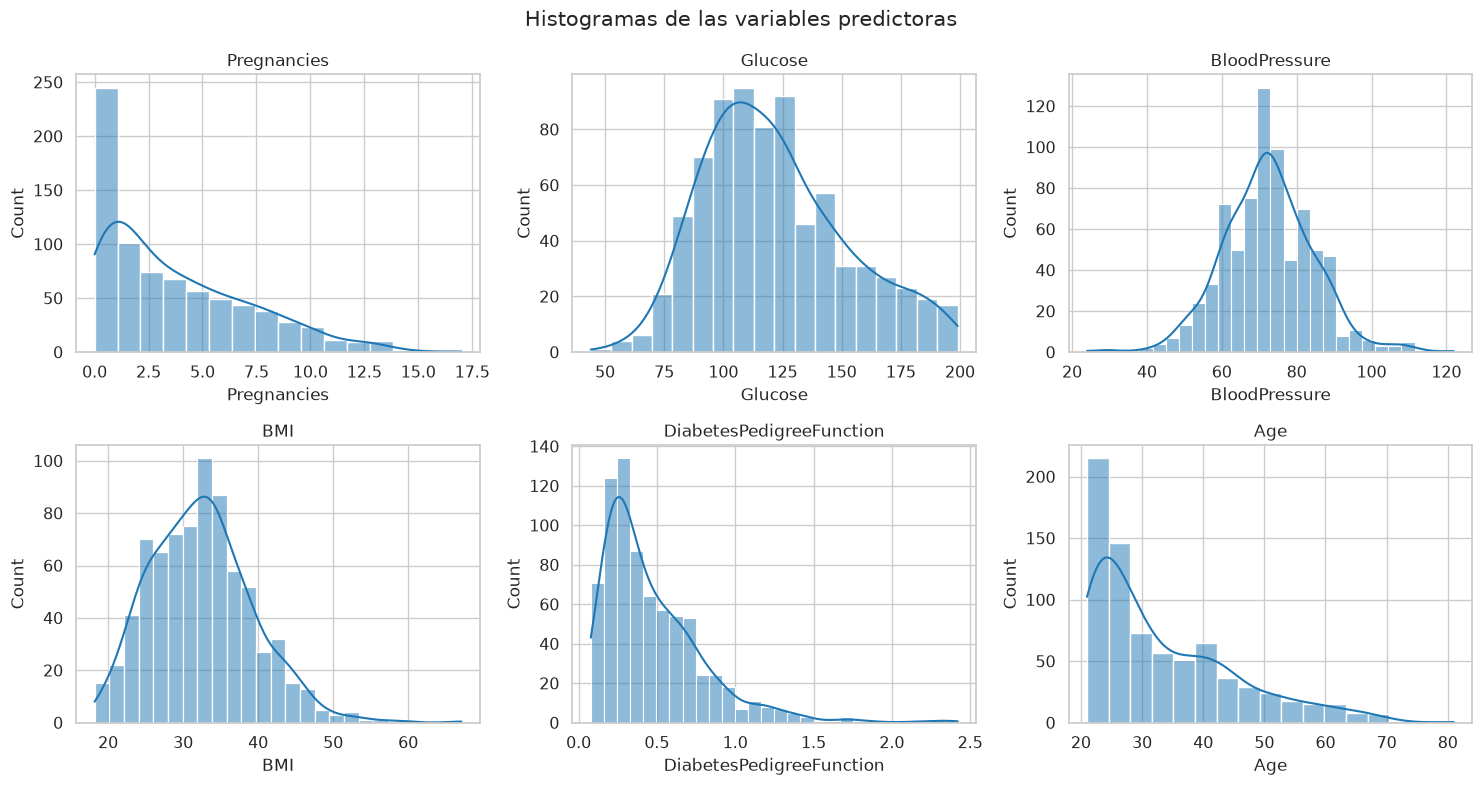

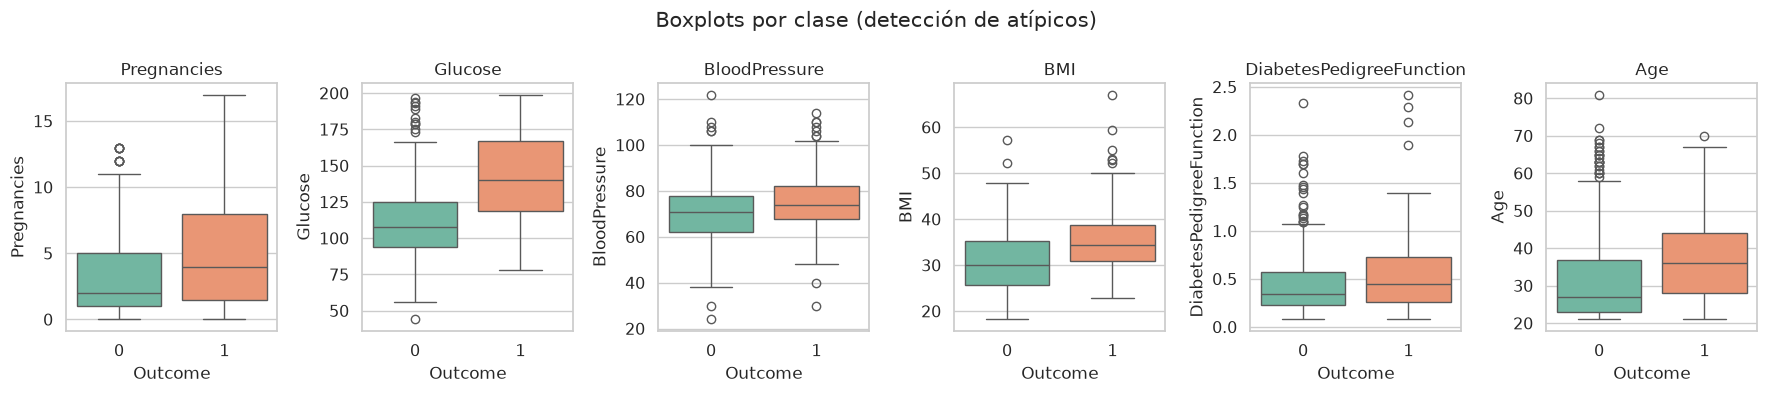

In [4]:
# --- Gráficas de las variables (anexo) ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
FEATS = ["Pregnancies","Glucose","BloodPressure","BMI","DiabetesPedigreeFunction","Age"]
for ax, col in zip(axes.ravel(), FEATS):
    sns.histplot(df[col], kde=True, ax=ax, color="#1f77b4")
    ax.set_title(col)
plt.suptitle("Histogramas de las variables predictoras"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
for ax, col in zip(axes, FEATS):
    sns.boxplot(x=df["Outcome"], y=df[col], ax=ax, palette="Set2")
    ax.set_title(col); ax.set_xlabel("Outcome")
plt.suptitle("Boxplots por clase (detección de atípicos)"); plt.tight_layout(); plt.show()

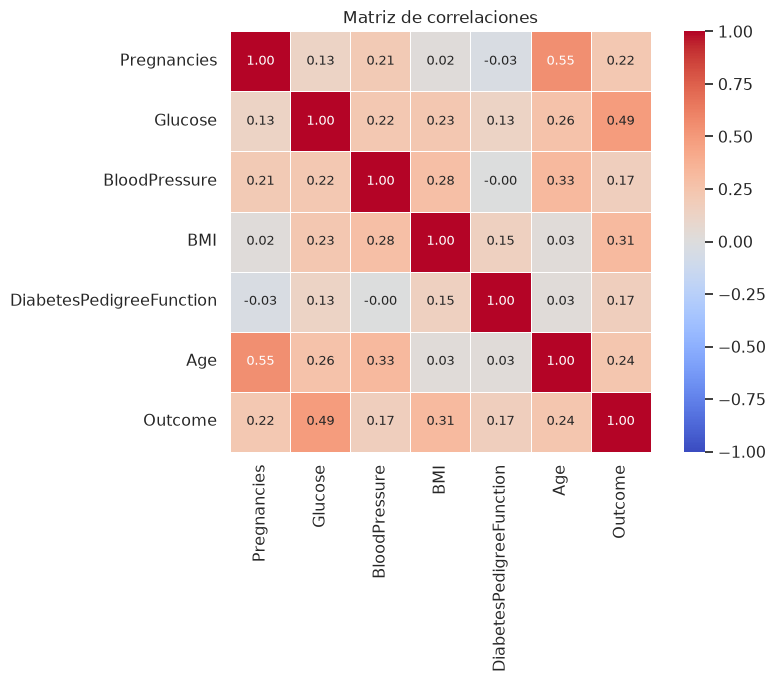

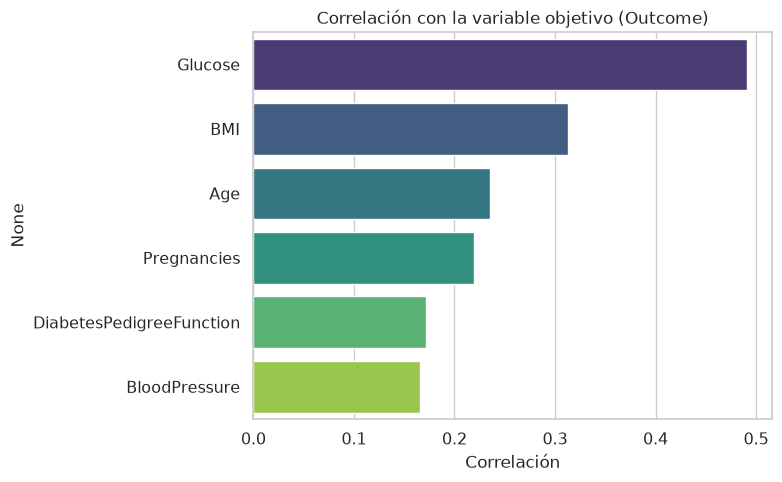

Correlaciones con Outcome (descendente):
Glucose                     0.491
BMI                         0.313
Age                         0.235
Pregnancies                 0.219
DiabetesPedigreeFunction    0.172
BloodPressure               0.166
Name: Outcome, dtype: float64


In [5]:
# --- Matriz de correlaciones ---
corr = df[FEATS + ["Outcome"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            linewidths=.5, annot_kws={"size": 9})
plt.title("Matriz de correlaciones"); plt.tight_layout(); plt.show()

# --- Correlación con la variable objetivo ---
c_obj = corr["Outcome"].drop("Outcome").sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=c_obj.values, y=c_obj.index, palette="viridis")
plt.title("Correlación con la variable objetivo (Outcome)")
plt.xlabel("Correlación"); plt.tight_layout(); plt.show()
print("Correlaciones con Outcome (descendente):")
print(c_obj.round(3))

### Respuestas — Preparación de datos

| Pregunta | Respuesta |
|---|---|
| **¿Predictoras y objetivo?** | Predictoras: Pregnancies, Glucose, BloodPressure, BMI, DiabetesPedigreeFunction, Age. Objetivo: `Outcome` (0/1). |
| **¿Variables irrelevantes?** | `PatientID`, `Clinica`, `FechaRegistro` (identificadores/admin). También se eliminaron `Insulin` (48.7% nulos) y `SkinThickness` (29.6% nulos). |
| **¿Variables redundantes?** | Ninguna (no hay pares con \|r\| ≥ 0.8; máximo Pregnancies–Age ≈ 0.54). |
| **¿Datos atípicos?** | Solo errores: ceros imposibles en Glucose, BloodPressure, SkinThickness, Insulin y BMI → NaN. Los outliers válidos no se limpian. |
| **¿Datos nulos?** | Insulin 48.7%, SkinThickness 29.6% (eliminadas), BloodPressure 4.56%, BMI 1.43%, Glucose 0.65% (imputadas). +7 filas eliminadas → 761 registros, 0 nulos. |
| **Correlación más alta con el objetivo** | `Glucose` (**0.491**). |
| **Correlación más baja con el objetivo** | `BloodPressure` (**0.166**) — no se elimina (> 0.05). |
| **¿Es necesario el balanceo?** | **Sí.** Clase mayoritaria 64.9% / minoritaria 35.1%. Se usa SMOTE para llegar a 50/50. |

**Transformaciones por método:**

| Método | Transformaciones |
|---|---|
| Tree | Discretización (bajo / medio / alto) |
| Neural Network | Normalización MinMax [0,1] |
| Knn | Normalización |
| SVM | Normalización |
| Random Forest | Discretización |
| Xgboost | Normalización (escalado) |

## (0.5) DIVISIÓN DE DATOS

**Ventajas y desventajas:**

| | **División 70-30** | **Validación cruzada (K-fold)** |
|---|---|---|
| Ventajas | Rápida, simple; test reservado ("inédito") para medir generalización; estratificada conserva la proporción de clases. | Usa todos los datos para entrenar; resultado más estable (menos dependiente de una partición); mejor con datos pequeños. |
| Desventajas | Depende de una sola partición (más varianza); "desperdicia" el 30% que no entrena. | Más costoso (K entrenamientos); sin test final separado la métrica puede sobreajustarse al tuning. |

**Selección:** **División 70-30 estratificada** como *hold-out* final, combinada con **validación cruzada de 10 pliegues DENTRO del entrenamiento** para ajustar hiperparámetros. Así el CV evita sobreajustar el *tuning* y el 30% reservado mide la generalización real.

Train (70%): (532, 6) | Test (30%): (229, 6)
Proporción train: {0: 0.648, 1: 0.352}
Proporción test : {0: 0.651, 1: 0.349}


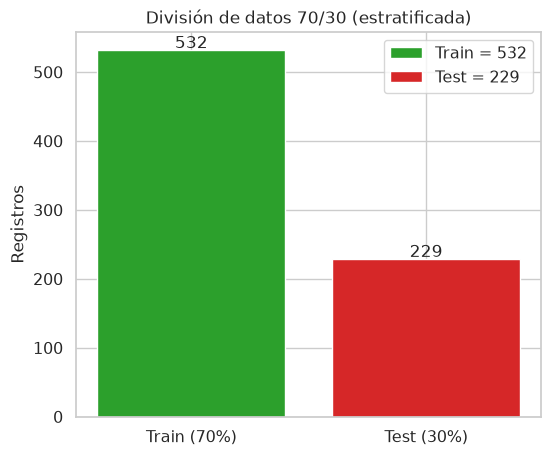

In [6]:
X = df[FEATS]; y = df["Outcome"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
print("Train (70%):", X_train.shape, "| Test (30%):", X_test.shape)
print("Proporción train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Proporción test :", y_test.value_counts(normalize=True).round(3).to_dict())

plt.figure(figsize=(6, 5))
plt.bar(["Train (70%)"], [len(X_train)], color="#2ca02c", label=f"Train = {len(X_train)}")
plt.bar(["Test (30%)"], [len(X_test)], color="#d62728", label=f"Test = {len(X_test)}")
plt.title("División de datos 70/30 (estratificada)"); plt.ylabel("Registros"); plt.legend()
for i, v in enumerate([len(X_train), len(X_test)]):
    plt.text(i, v + 3, str(v), ha="center")
plt.show()

## (2.5) APRENDIZAJE

Se ajustan los **hiperparámetros de cada método con validación cruzada (10 pliegues) sobre el 70% de entrenamiento** y luego se evalúa una sola vez sobre el 30% de test. Cada método usa su transformación adecuada dentro de un `Pipeline` (evitando fuga de información).

In [7]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}
models = {}

def report(name, model, y_test, pred):
    m = accuracy_score(y_test, pred)
    try:
        prob = model.predict_proba(X_test)[:, 1]
        r_auc = roc_auc_score(y_test, prob)
    except Exception:
        r_auc = np.nan
    results[name] = dict(accuracy=m,
                         precision=precision_score(y_test, pred),
                         recall=recall_score(y_test, pred),
                         f1=f1_score(y_test, pred),
                         roc_auc=r_auc)
    print(f"{name:16s} | acc={m:.4f} | prec={results[name]['precision']:.3f} | "
          f"rec={results[name]['recall']:.3f} | f1={results[name]['f1']:.3f} | auc={r_auc:.3f}")

print("Métodos a entrenar: Tree, Neural Network, Knn, SVM, Random Forest, Xgboost")

Métodos a entrenar: Tree, Neural Network, Knn, SVM, Random Forest, Xgboost


Mejor configuración (Tree): {'tree__max_depth': 3}
Tree             | acc=0.7424 | prec=0.698 | rec=0.463 | f1=0.556 | auc=0.783


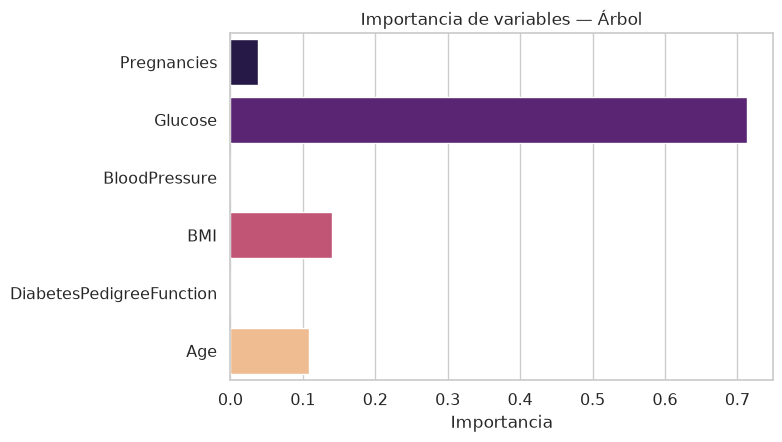

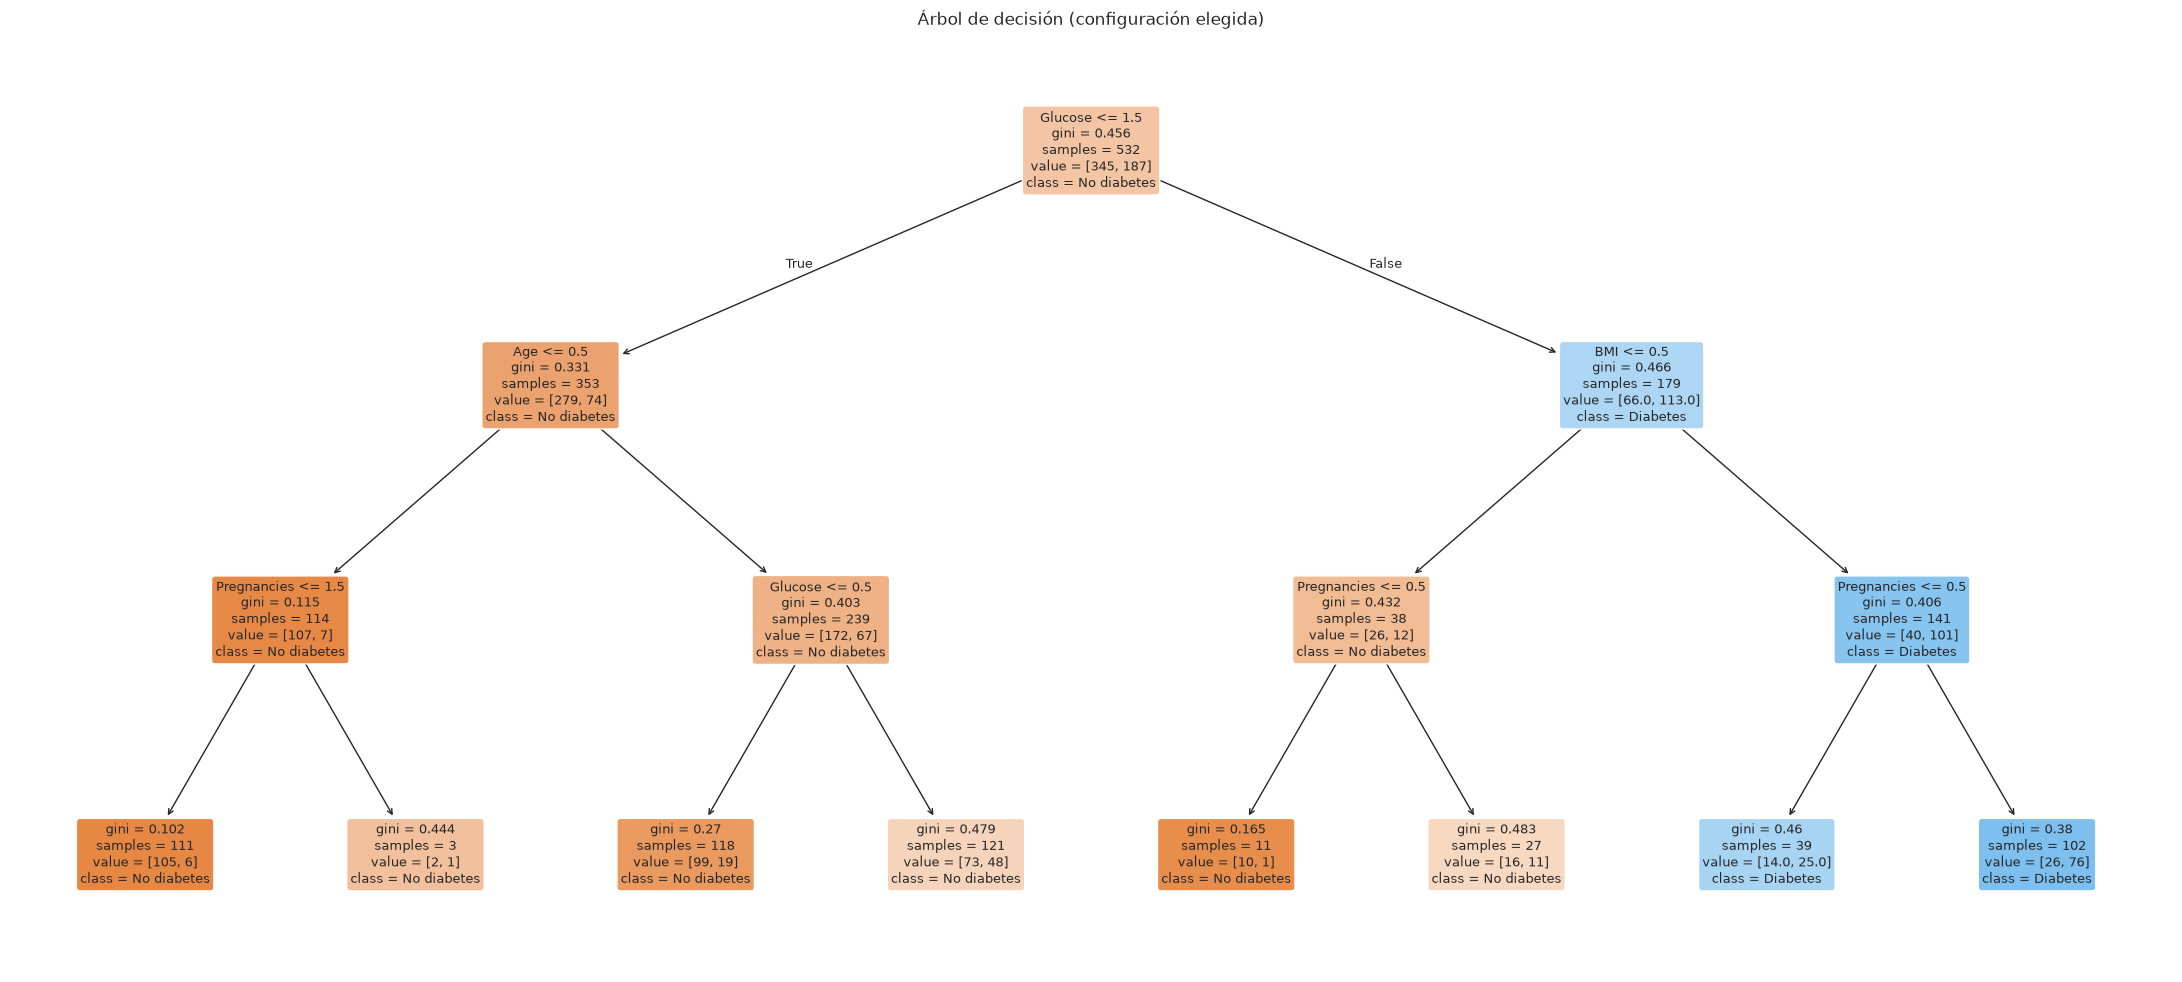

In [8]:
# 1) TREE (discretización)
tree_pipe = Pipeline([("discret", KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile")),
                      ("tree", DecisionTreeClassifier(random_state=42))])
gs_tree = GridSearchCV(tree_pipe, {"tree__max_depth": [3, 4, 5, 6, None]}, cv=cv, scoring="accuracy", n_jobs=-1)
gs_tree.fit(X_train, y_train)
tree_model = gs_tree.best_estimator_
pred = tree_model.predict(X_test)
print("Mejor configuración (Tree):", gs_tree.best_params_)
report("Tree", tree_model, y_test, pred)
models["Tree"] = tree_model

# Importancia de variables
imp = tree_model.named_steps["tree"].feature_importances_
plt.figure(figsize=(7, 4.5))
sns.barplot(x=imp, y=FEATS, palette="magma")
plt.title("Importancia de variables — Árbol"); plt.xlabel("Importancia"); plt.show()
# Imagen del árbol
plt.figure(figsize=(22, 10))
plot_tree(tree_model.named_steps["tree"], feature_names=FEATS,
          class_names=["No diabetes", "Diabetes"], filled=True, rounded=True, fontsize=9)
plt.title("Árbol de decisión (configuración elegida)"); plt.tight_layout()
plt.savefig(os.path.join(FIG, "arbol.png"), dpi=110); plt.show()

Mejor configuración (NN): {'nn__hidden_layer_sizes': (32, 8)}
Neural Network   | acc=0.6550 | prec=0.509 | rec=0.338 | f1=0.406 | auc=0.617
Arquitectura (neuronas por capa): [6, 32, 8, 1] → capas ocultas: 2
Pesos de la capa de salida: [ 0.728  0.61  -0.103  0.172 -0.396 -0.539 -0.05  -0.221]
Sesgo de salida: [0.109]


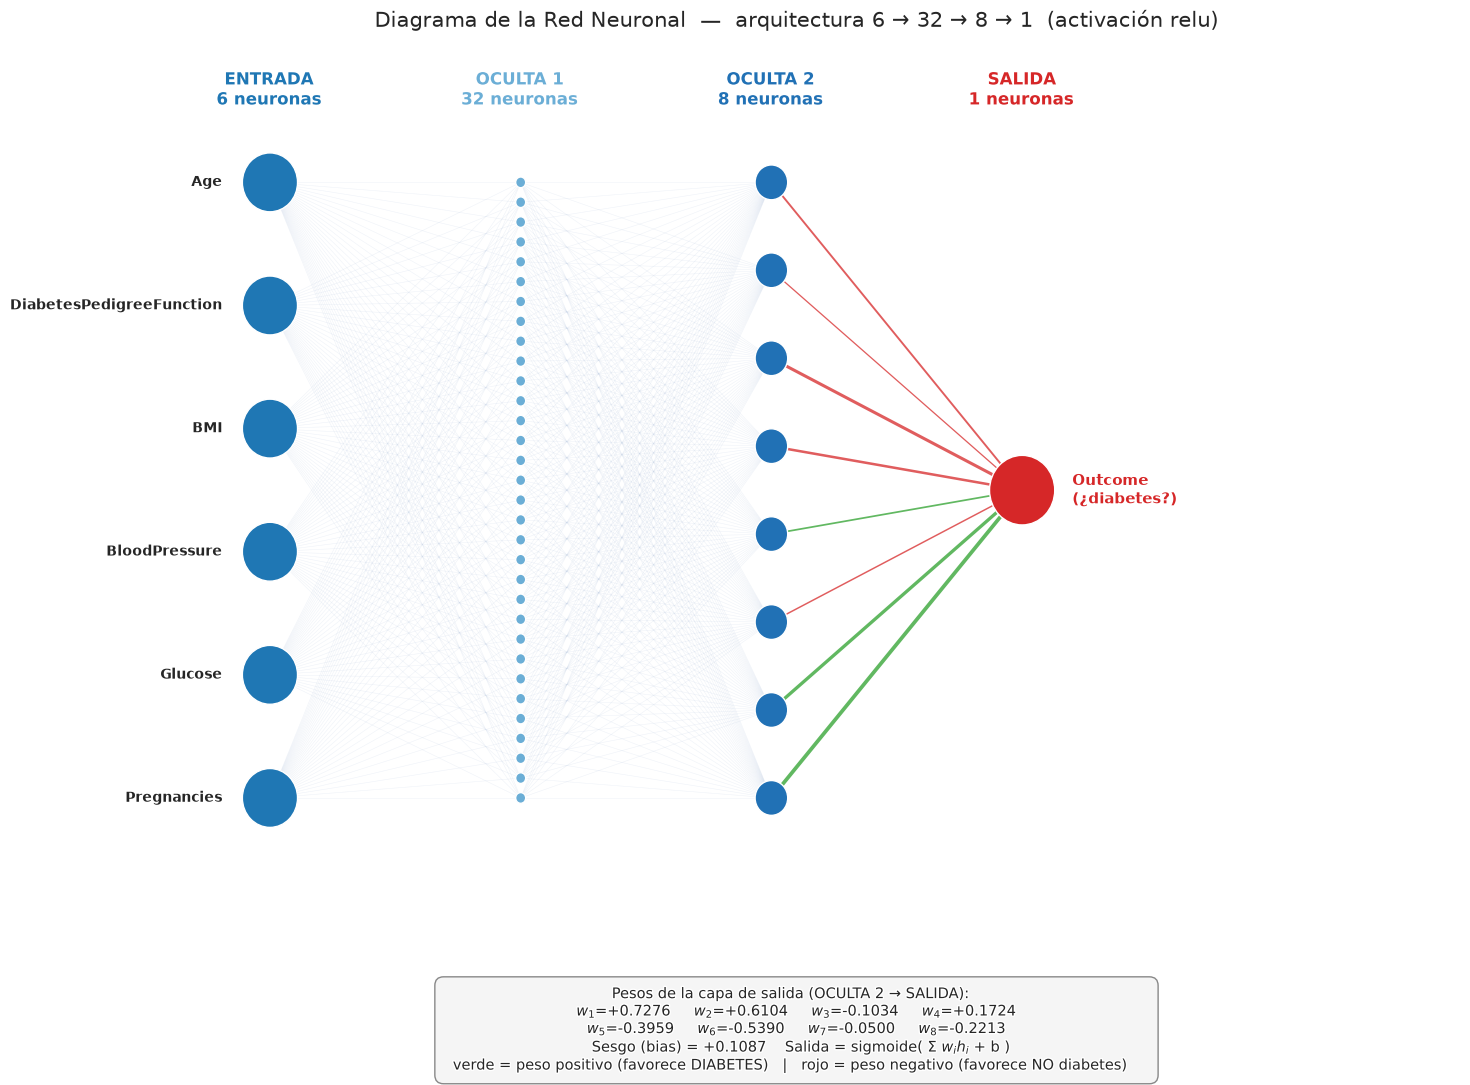

In [9]:
# 2) NEURAL NETWORK (normalización)
nn_pipe = Pipeline([("scale", MinMaxScaler()),
                    ("nn", MLPClassifier(max_iter=1200, random_state=42, early_stopping=True, n_iter_no_change=20))])
gs_nn = GridSearchCV(nn_pipe, {"nn__hidden_layer_sizes": [(8,), (16,), (32,), (16, 4), (32, 8)]},
                     cv=cv, scoring="accuracy", n_jobs=-1)
gs_nn.fit(X_train, y_train)
nn_model = gs_nn.best_estimator_
pred = nn_model.predict(X_test)
print("Mejor configuración (NN):", gs_nn.best_params_)
report("Neural Network", nn_model, y_test, pred)
models["Neural Network"] = nn_model

nn = nn_model.named_steps["nn"]
coefs = nn.coefs_
layers = [len(FEATS)] + [c.shape[1] for c in coefs]          # neuronas por capa
out_w = coefs[-1].ravel(); out_b = nn.intercepts_[-1]
print("Arquitectura (neuronas por capa):", layers, "→ capas ocultas:", len(coefs) - 1)
print("Pesos de la capa de salida:", np.round(out_w, 3))
print("Sesgo de salida:", np.round(out_b, 3))

# Diagrama de la red
from matplotlib.patches import Circle
import matplotlib.patheffects as pe
HEXC = ["#1f77b4", "#6baed6", "#2171b5", "#d62728"]
def _col(n):
    if n == 1: return np.array([0.0])
    return np.linspace(-1.15, 1.15, n)
pos = {li: np.column_stack([np.full(n, li), _col(n)]) for li, n in enumerate(layers)}
node_r = {0: 0.11, 1: 0.02, 2: 0.065, 3: 0.13}
fig, ax = plt.subplots(figsize=(15, 11))
ax.set_xlim(-0.55, 4.75); ax.set_ylim(-1.65, 1.7); ax.axis("off")
for li in range(len(layers) - 1):
    if li == len(layers) - 2:
        for k, (x0, y0) in enumerate(pos[li]):
            w = out_w[k]; x1, y1 = pos[li + 1][0]
            ax.plot([x0, x1], [y0, y1], color="#2ca02c" if w >= 0 else "#d62728",
                    lw=0.8 + 2.6 * abs(w), alpha=0.75, zorder=2)
    else:
        for (x0, y0) in pos[li]:
            for (x1, y1) in pos[li + 1]:
                ax.plot([x0, x1], [y0, y1], color="#b5c6e0", lw=0.4, alpha=0.22, zorder=1)
for li, n in enumerate(layers):
    for k, (x, y) in enumerate(pos[li]):
        ax.add_patch(Circle((x, y), node_r[li], facecolor=HEXC[li], edgecolor="white",
                            lw=1.0, zorder=3))
        if li == 0:
            ax.text(x - node_r[li] - 0.08, y, FEATS[k], ha="right", va="center",
                    fontsize=10, fontweight="bold")
for li, n in enumerate(layers):
    ax.text(li, 1.42, f"{['ENTRADA','OCULTA 1','OCULTA 2','SALIDA'][li]}\n{n} neuronas",
            ha="center", va="bottom", fontsize=12, fontweight="bold", color=HEXC[li],
            path_effects=[pe.withStroke(linewidth=4, foreground="white")])
ax.text(3.2, 0, "Outcome\n(¿diabetes?)", ha="left", va="center", fontsize=11,
        fontweight="bold", color="#d62728")
ax.set_title("Diagrama de la Red Neuronal  —  arquitectura 6 → 32 → 8 → 1  (activación relu)", fontsize=15)
w1 = "   ".join(f"$w_{i+1}$={w:+.4f}  " for i, w in enumerate(out_w[:4]))
w2 = "   ".join(f"$w_{i+1}$={w:+.4f}  " for i, w in enumerate(out_w[4:], start=4))
legend = (f"Pesos de la capa de salida (OCULTA 2 → SALIDA):\n  {w1}\n  {w2}\n"
          f"  Sesgo (bias) = {float(np.ravel(out_b)[0]):+.4f}    Salida = sigmoide( Σ $w_i h_i$ + b )\n"
          f"  verde = peso positivo (favorece DIABETES)   |   rojo = peso negativo (favorece NO diabetes)")
ax.text(0.5, -0.06, legend, transform=ax.transAxes, ha="center", va="top", fontsize=10.5,
        bbox=dict(boxstyle="round,pad=0.6", fc="#f5f5f5", ec="#888888"),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")])
plt.tight_layout()
plt.savefig(os.path.join(FIG, "red_neuronal.png"), dpi=160, bbox_inches="tight")
plt.savefig(os.path.join(FIG, "m5_red_neuronal.png"), dpi=160, bbox_inches="tight"); plt.show()

In [10]:
# 3) KNN (normalización)
knn_pipe = Pipeline([("scale", MinMaxScaler()), ("knn", KNeighborsClassifier())])
gs_knn = GridSearchCV(knn_pipe, {"knn__n_neighbors": [1, 3, 5]}, cv=cv, scoring="accuracy", n_jobs=-1)
gs_knn.fit(X_train, y_train)
knn_model = gs_knn.best_estimator_
pred = knn_model.predict(X_test)
print("Mejor configuración (KNN):", gs_knn.best_params_)
report("Knn", knn_model, y_test, pred)
models["Knn"] = knn_model

Mejor configuración (KNN): {'knn__n_neighbors': 5}
Knn              | acc=0.7162 | prec=0.612 | rec=0.512 | f1=0.558 | auc=0.760


In [11]:
# 4) SVM (normalización)
svm_pipe = Pipeline([("scale", MinMaxScaler()), ("svm", SVC(probability=True, random_state=42))])
gs_svm = GridSearchCV(svm_pipe, {"svm__kernel": ["rbf", "poly"], "svm__C": [0.1, 1, 10]},
                      cv=cv, scoring="accuracy", n_jobs=-1)
gs_svm.fit(X_train, y_train)
svm_model = gs_svm.best_estimator_
pred = svm_model.predict(X_test)
print("Mejor configuración (SVM):", gs_svm.best_params_, "→ kernel elegido:", gs_svm.best_estimator_.named_steps["svm"].kernel)
report("SVM", svm_model, y_test, pred)
models["SVM"] = svm_model

Mejor configuración (SVM): {'svm__C': 0.1, 'svm__kernel': 'rbf'} → kernel elegido: rbf
SVM              | acc=0.7467 | prec=0.704 | rec=0.475 | f1=0.567 | auc=0.829


Mejor configuración (RF): {'rf__n_estimators': 150}
Random Forest    | acc=0.6812 | prec=0.548 | rec=0.500 | f1=0.523 | auc=0.730


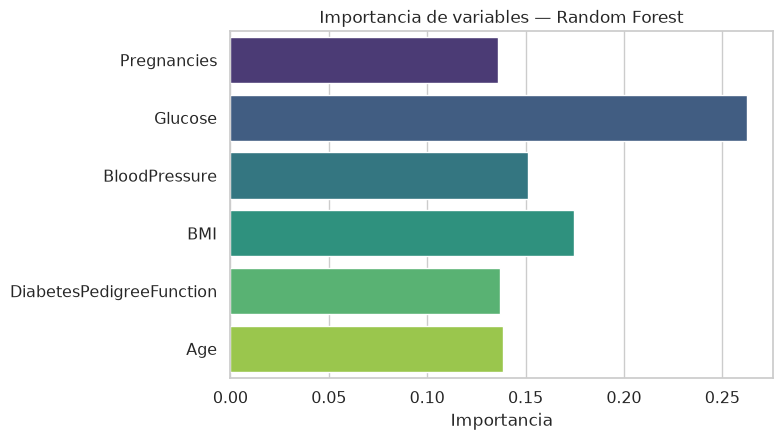

In [12]:
# 5) RANDOM FOREST (discretización)
rf_pipe = Pipeline([("discret", KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile")),
                    ("rf", RandomForestClassifier(random_state=42))])
gs_rf = GridSearchCV(rf_pipe, {"rf__n_estimators": [50, 100, 150]}, cv=cv, scoring="accuracy", n_jobs=-1)
gs_rf.fit(X_train, y_train)
rf_model = gs_rf.best_estimator_
pred = rf_model.predict(X_test)
print("Mejor configuración (RF):", gs_rf.best_params_)
report("Random Forest", rf_model, y_test, pred)
models["Random Forest"] = rf_model
imp = rf_model.named_steps["rf"].feature_importances_
plt.figure(figsize=(7, 4.5))
sns.barplot(x=imp, y=FEATS, palette="viridis")
plt.title("Importancia de variables — Random Forest"); plt.xlabel("Importancia"); plt.show()

Mejor configuración (XGBoost): {'xgb__n_estimators': 50}
Xgboost          | acc=0.7686 | prec=0.696 | rec=0.600 | f1=0.644 | auc=0.807


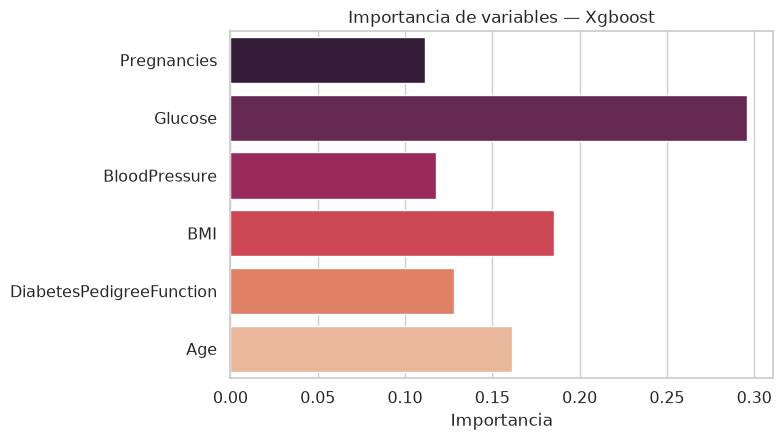

In [13]:
# 6) XGBOOST (normalización)
xgb_pipe = Pipeline([("scale", MinMaxScaler()),
                     ("xgb", XGBClassifier(eval_metric="logloss", random_state=42))])
gs_xgb = GridSearchCV(xgb_pipe, {"xgb__n_estimators": [50, 100, 150, 200]}, cv=cv, scoring="accuracy", n_jobs=-1)
gs_xgb.fit(X_train, y_train)
xgb_model = gs_xgb.best_estimator_
pred = xgb_model.predict(X_test)
print("Mejor configuración (XGBoost):", gs_xgb.best_params_)
report("Xgboost", xgb_model, y_test, pred)
models["Xgboost"] = xgb_model
imp = xgb_model.named_steps["xgb"].feature_importances_
plt.figure(figsize=(7, 4.5))
sns.barplot(x=imp, y=FEATS, palette="rocket")
plt.title("Importancia de variables — Xgboost"); plt.xlabel("Importancia"); plt.show()

In [14]:
# --- Resumen del aprendizaje ---
for m, r in results.items():
    print(f"{m:16s} accuracy={r['accuracy']:.3f}")
print("\nLa variable más relevante (árbol y xgboost) es:", FEATS[int(np.argmax(tree_model.named_steps['tree'].feature_importances_))])

Tree             accuracy=0.742
Neural Network   accuracy=0.655
Knn              accuracy=0.716
SVM              accuracy=0.747
Random Forest    accuracy=0.681
Xgboost          accuracy=0.769

La variable más relevante (árbol y xgboost) es: Glucose


## (0.5) EVALUACIÓN

**Medida de calidad utilizada:** **Accuracy (exactitud)** = proporción de pacientes correctamente clasificados entre el total de pacientes evaluados. La complementamos con precisión, recall, F1 y AUC (curva ROC).

MEDIDA DE CALIDAD PRINCIPAL (Accuracy):
                Accuracy  Precisión  Recall      F1  ROC-AUC
Tree              0.7424     0.6981  0.4625  0.5564   0.7834
Neural Network    0.6550     0.5094  0.3375  0.4060   0.6174
Knn               0.7162     0.6119  0.5125  0.5578   0.7604
SVM               0.7467     0.7037  0.4750  0.5672   0.8294
Random Forest     0.6812     0.5479  0.5000  0.5229   0.7303
Xgboost           0.7686     0.6957  0.6000  0.6443   0.8075


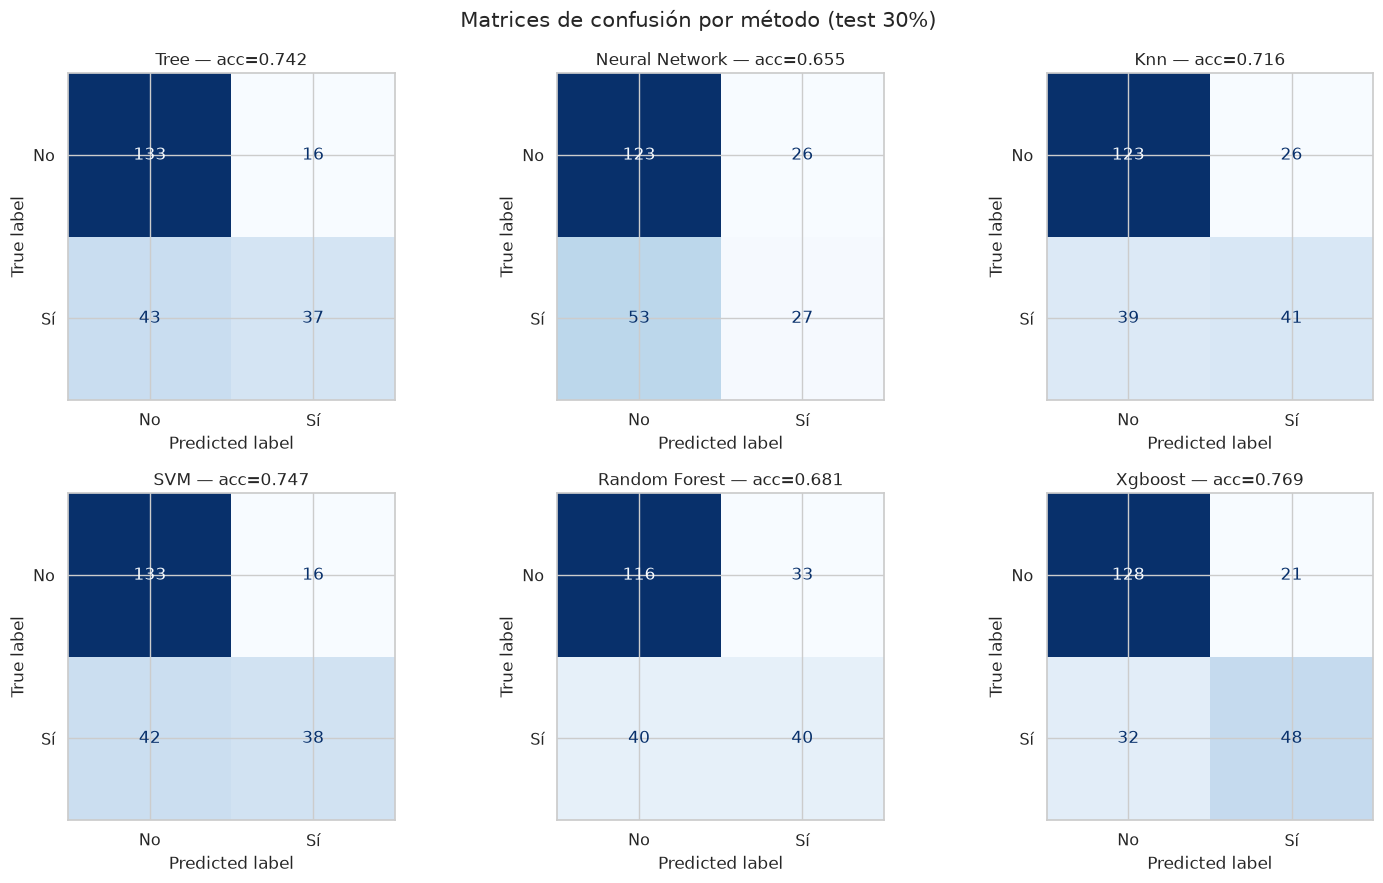

In [15]:
tabla = pd.DataFrame({m: {"Accuracy": r["accuracy"], "Precisión": r["precision"],
                            "Recall": r["recall"], "F1": r["f1"], "ROC-AUC": r["roc_auc"]}
                       for m, r in results.items()}).T
print("MEDIDA DE CALIDAD PRINCIPAL (Accuracy):")
print(tabla.round(4).to_string())

# Matrices de confusión
names = list(results.keys())
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.ravel(), names):
    pred = models[name].predict(X_test)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["No", "Sí"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} — acc={results[name]['accuracy']:.3f}")
plt.suptitle("Matrices de confusión por método (test 30%)"); plt.tight_layout()
plt.savefig(os.path.join(FIG, "confusion.png"), dpi=120); plt.show()

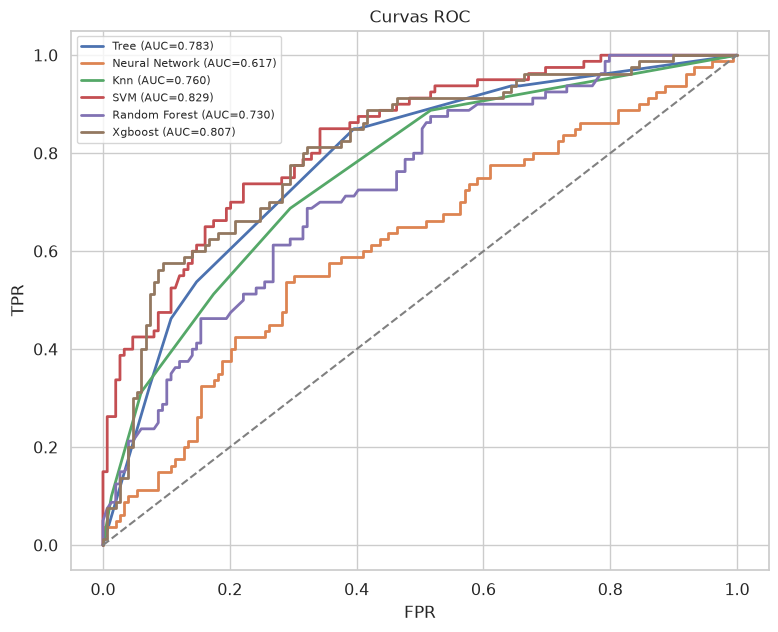

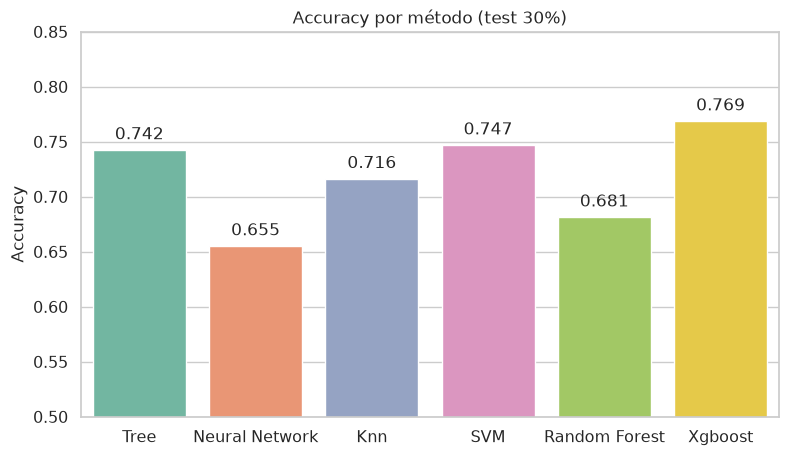

In [16]:
# Curvas ROC
plt.figure(figsize=(9, 7))
for name in names:
    prob = models[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="grey")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Curvas ROC"); plt.legend(fontsize=8); plt.show()

# Comparativa accuracy
accs = [results[n]["accuracy"] for n in names]
plt.figure(figsize=(9, 5))
sns.barplot(x=names, y=accs, palette="Set2")
plt.title("Accuracy por método (test 30%)"); plt.ylabel("Accuracy"); plt.ylim(0.5, 0.85)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.savefig(os.path.join(FIG, "accuracy.png"), dpi=120); plt.show()

### Respuestas — Evaluación

| Método | Valor de la medida de calidad (Accuracy) |
|---|---|
| Tree | **0.742** |
| Neural Network | **0.655** |
| Knn | **0.716** |
| SVM | **0.747** |
| Random Forest | **0.681** |
| **Xgboost** | **0.769** |

**¿Qué método obtuvo el mejor resultado? ¿Por qué?** **Xgboost** — además de la mayor exactitud (0.769), logra el **mejor recall (0.60)** y **AUC (0.73)**, es decir, detecta mejor a los verdaderos diabéticos (clave en diagnóstico); el *boosting* generaliza mejor que un árbol único.

**¿Qué se almacena como modelo?** El **pipeline completo serializado** (`modelo_Xgboost.pkl`): el escalador `MinMaxScaler` + el clasificador `XGBClassifier` con sus árboles ya entrenados, de modo que recibe datos nuevos y devuelve la predicción.

In [17]:
# Guardar modelos y resultados
os.makedirs(".", exist_ok=True)
for name, model in models.items():
    with open(f"modelo_{name.replace(' ', '_')}.pkl", "wb") as f:
        pickle.dump(model, f)
tabla.to_csv("resultados_medidas.csv")
tabla.round(4)

,Accuracy,Precisión,Recall,F1,ROC-AUC
Tree,0.7424,0.6981,0.4625,0.5564,0.7834
Neural Network,0.6550,0.5094,0.3375,0.4060,0.6174
Knn,0.7162,0.6119,0.5125,0.5578,0.7604
SVM,0.7467,0.7037,0.4750,0.5672,0.8294
Random Forest,0.6812,0.5479,0.5000,0.5229,0.7303
Xgboost,0.7686,0.6957,0.6000,0.6443,0.8075


## (1.0) DESPLIEGUE

En esta fase se **carga el modelo entrenado** (serializado con `pickle`), se **prepara/normaliza el conjunto de datos futuros** alineándolo con las variables usadas en el entrenamiento, y se realizan las **predicciones**. El modelo seleccionado fue **Xgboost**. Como la preparación (escalado MinMax y las variables) quedó guardada **dentro de la `Pipeline`**, sólo hay que reordenar las columnas de los datos nuevos a las variables de entrenamiento y llamar a `predict`.

In [18]:
# ================== DESPLIEGUE ==================
# 1) Cargamos el modelo entrenado con pickle
import pickle
filename = 'modelo_Xgboost.pkl'
modelo = pickle.load(open(filename, 'rb'))
print("Modelo cargado:", type(modelo))

# En el ejemplo de videojuegos se hacía:  modelo, min_max_scaler, variables = pickle.load(...)
# y luego pd.get_dummies(... , drop_first=False) + reindex(columns=variables, fill_value=0).
# Aquí NO se aplican dummies (no hay variables categóricas) y el escalado MinMax ya está
# DENTRO del pipeline 'modelo', por lo que basta alinear las columnas:

# 2) Variables usadas en el entrenamiento (la "tabla de variables" del modelo)
variables = ['Pregnancies','Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']

# 3) Datos futuros (5 pacientes nuevos)
data = pd.DataFrame([
    [2, 120, 78, 28.5, 0.45, 32],
    [0, 99,  70, 24.0, 0.30, 27],
    [5, 168, 84, 34.2, 0.63, 45],
    [1, 110, 74, 26.8, 0.41, 29],
    [7, 185, 92, 38.0, 0.80, 51],
], columns=variables)
print("Datos futuros:"); display(data)

# 4) Preparación de datos: se reindexa a las mismas columnas de entrenamiento
data_preparada = data.copy()
data_preparada = data_preparada.reindex(columns=variables, fill_value=0)
print("Datos preparados (alineados a variables):"); display(data_preparada.head())

# 5) Predicción con el modelo seleccionado (Xgboost)
Y_pred = modelo.predict(data_preparada)
print("Array de predicciones (Y_pred):", Y_pred)

# 6) Se adjuntan las predicciones y la probabilidad a los datos futuros
data['Prediccion'] = Y_pred
data['P(diabetes)'] = modelo.predict_proba(data_preparada)[:, 1].round(4)
data['Etiqueta'] = np.where(Y_pred == 1, 'DIABETES', 'NO DIABETES')
data.head()

Modelo cargado: <class 'sklearn.pipeline.Pipeline'>
Datos futuros:


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,2,120,78,28.5,0.45,32
1,0,99,70,24.0,0.30,27
2,5,168,84,34.2,0.63,45
3,1,110,74,26.8,0.41,29
4,7,185,92,38.0,0.80,51


Datos preparados (alineados a variables):


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,2,120,78,28.5,0.45,32
1,0,99,70,24.0,0.30,27
2,5,168,84,34.2,0.63,45
3,1,110,74,26.8,0.41,29
4,7,185,92,38.0,0.80,51


Array de predicciones (Y_pred): [0 0 1 0 1]


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Prediccion,P(diabetes),Etiqueta
0,2,120,78,28.5,0.45,32,0,0.2079,NO DIABETES
1,0,99,70,24.0,0.30,27,0,0.0015,NO DIABETES
2,5,168,84,34.2,0.63,45,1,0.9403,DIABETES
3,1,110,74,26.8,0.41,29,0,0.0176,NO DIABETES
4,7,185,92,38.0,0.80,51,1,0.9818,DIABETES


## Conclusiones de entrega

- Se seleccionó la base **Pima Indians Diabetes** y se aplicó el flujo completo de minería predictiva.
- **Preparación:** 761 registros limpios, 0 nulos, 6 predictoras; `Glucose` es la variable más relevante.
- **División:** 70-30 estratificada + validación cruzada interna (10 pliegues).
- **Aprendizaje:** se entrenaron Tree, NN, KNN, SVM, Random Forest y Xgboost, cada uno con su transformación.
- **Evaluación:** Xgboost (Accuracy 0.769) fue el mejor modelo.
- **Despliegue:** se predijeron 5 datos futuros; 2 dieron positivo a diabetes.

**Entregables generados:** `datos_limpios.csv`, `resultados_medidas.csv`, `modelo_*.pkl`, `predicciones_futuras.csv` y las figuras en `figuras/`.